<a href="https://colab.research.google.com/github/efulii/makine-ogrenmesi-final/blob/main/ML_Final_%C3%96devi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
!pip install xgboost -q


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sonuçların her seferinde aynı çıkması için rastgelelik tohumu
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [17]:
!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/00280/HIGGS.csv.gz
!ls -lh HIGGS.csv.gz   # dosya indi mi diye kontrol

-rw-r--r-- 1 root root 2.7G Jun  4 09:59 HIGGS.csv.gz


In [18]:
# HIGGS'in 29 sütunu var: 1 etiket (signal/background) + 28 özellik
column_names = [
    "label",
    "lepton_pT", "lepton_eta", "lepton_phi",
    "missing_energy_mag", "missing_energy_phi",
    "jet1_pt", "jet1_eta", "jet1_phi", "jet1_btag",
    "jet2_pt", "jet2_eta", "jet2_phi", "jet2_btag",
    "jet3_pt", "jet3_eta", "jet3_phi", "jet3_btag",
    "jet4_pt", "jet4_eta", "jet4_phi", "jet4_btag",
    "m_jj", "m_jjj", "m_lv", "m_jlv", "m_bb", "m_wbb", "m_wwbb"
]

# Dosyayı 500.000'lik parçalar halinde oku, her parçadan rastgele örnek al
chunks = []
samples_per_chunk = 5000   # her parçadan kaç örnek alacağız

for chunk in pd.read_csv("HIGGS.csv.gz", header=None, names=column_names,
                         chunksize=500_000):
    chunks.append(chunk.sample(n=samples_per_chunk, random_state=RANDOM_STATE))

# Topladığımız örnekleri birleştir ve tam 100.000'e indir, karıştır
df = pd.concat(chunks).sample(n=100_000, random_state=RANDOM_STATE).reset_index(drop=True)

print("Veri boyutu:", df.shape)   # (100000, 29) çıkmalı
df.head()

Veri boyutu: (100000, 29)


,label,lepton_pT,lepton_eta,lepton_phi,missing_energy_mag,missing_energy_phi,jet1_pt,jet1_eta,jet1_phi,jet1_btag,...,jet4_eta,jet4_phi,jet4_btag,m_jj,m_jjj,m_lv,m_jlv,m_bb,m_wbb,m_wwbb
0,1.0,0.635774,-1.062654,1.251074,1.431667,0.561306,0.839855,0.402998,-0.787157,2.173076,...,0.716600,0.531999,1.550981,1.444517,0.846338,0.988854,1.804098,0.590048,1.170901,1.139615
1,0.0,2.578781,0.488878,-1.333575,0.705771,1.695338,1.076660,0.291102,0.275685,2.173076,...,0.778229,0.546427,3.101961,1.700755,1.395261,1.001401,1.575796,0.327974,1.272300,1.473662
2,0.0,1.319496,-0.187056,-1.386287,0.833538,1.326575,2.010504,0.600054,-0.149623,1.086538,...,0.193587,1.347720,0.000000,0.936643,0.995001,0.986776,1.696205,1.345798,1.239508,1.099962
3,0.0,0.880091,-0.256208,-1.368532,1.344133,1.077844,0.662687,0.008887,0.139309,2.173076,...,0.264377,-0.997999,0.000000,0.826996,1.160398,1.213875,0.872393,0.752442,0.982192,0.946116
4,1.0,1.102447,1.627448,1.458037,0.984657,0.476618,0.790570,0.963468,-1.027756,1.086538,...,1.867562,-0.997999,0.000000,0.871291,0.856706,1.116071,0.524133,0.712079,0.699170,0.619899


In [19]:
# Sütun tipleri ve eksik (boş) değer var mı?
print("--- Sütun bilgileri ---")
df.info()

print("\n--- Her sütunda kaç eksik değer var? ---")
print(df.isnull().sum())

--- Sütun bilgileri ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 29 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   label               100000 non-null  float64
 1   lepton_pT           100000 non-null  float64
 2   lepton_eta          100000 non-null  float64
 3   lepton_phi          100000 non-null  float64
 4   missing_energy_mag  100000 non-null  float64
 5   missing_energy_phi  100000 non-null  float64
 6   jet1_pt             100000 non-null  float64
 7   jet1_eta            100000 non-null  float64
 8   jet1_phi            100000 non-null  float64
 9   jet1_btag           100000 non-null  float64
 10  jet2_pt             100000 non-null  float64
 11  jet2_eta            100000 non-null  float64
 12  jet2_phi            100000 non-null  float64
 13  jet2_btag           100000 non-null  float64
 14  jet3_pt             100000 non-null  float64
 15  jet3_eta   

In [20]:
# 0 ve 1 sınıfları ne kadar dengeli?
print(df["label"].value_counts())
print("\nOranlar:")
print(df["label"].value_counts(normalize=True))

label
1.0    53130
0.0    46870
Name: count, dtype: int64

Oranlar:
label
1.0    0.5313
0.0    0.4687
Name: proportion, dtype: float64


In [21]:
# Her özelliğin ortalama, min, max, çeyreklik değerleri
df.describe()

,label,lepton_pT,lepton_eta,lepton_phi,missing_energy_mag,missing_energy_phi,jet1_pt,jet1_eta,jet1_phi,jet1_btag,...,jet4_eta,jet4_phi,jet4_btag,m_jj,m_jjj,m_lv,m_jlv,m_bb,m_wbb,m_wwbb
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.531300,0.992079,0.004458,0.002731,0.995678,-0.002457,0.991427,0.001518,0.003502,0.998854,...,0.002048,0.002272,0.999498,1.030972,1.023690,1.049618,1.007336,0.972742,1.031488,0.958615
std,0.499022,0.565914,1.009297,1.007248,0.597061,1.005238,0.473800,1.008669,1.004736,1.027233,...,1.007861,1.007155,1.399452,0.653199,0.369359,0.162813,0.392965,0.524290,0.357084,0.306220
min,0.000000,0.274697,-2.433028,-1.742508,0.001475,-1.743910,0.145014,-2.966754,-1.741237,0.000000,...,-2.497265,-1.742691,0.000000,0.111076,0.315884,0.163004,0.283526,0.060031,0.362456,0.347443
25%,0.000000,0.592034,-0.733453,-0.869157,0.576292,-0.872258,0.679703,-0.685265,-0.861998,0.000000,...,-0.713357,-0.870369,0.000000,0.790845,0.846677,0.985746,0.765842,0.674830,0.820024,0.771461
50%,1.000000,0.853554,0.003842,0.005410,0.889021,-0.002799,0.896651,0.000965,0.010694,1.086538,...,0.001205,0.002058,0.000000,0.894763,0.951620,0.989774,0.915161,0.873621,0.947261,0.872985
75%,1.000000,1.238240,0.742110,0.871549,1.290744,0.861661,1.171656,0.685214,0.871639,2.173076,...,0.716600,0.876183,3.101961,1.024998,1.085118,1.018491,1.140946,1.138857,1.141422,1.058699
max,1.000000,8.611493,2.432920,1.743236,7.615502,1.743240,6.211885,2.968684,1.741454,2.173076,...,2.498009,1.743372,3.101961,20.944115,10.411252,6.691249,7.948525,10.692902,6.449260,4.430474


In [22]:
# Etiket dışındaki tüm özellikleri al
features = df.columns.drop("label")

# Her özellik için IQR sınırlarını hesapla ve aykırı değer sayısını bul
outlier_summary = {}
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    # Sınırların dışında kalan satır sayısı
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = n_outliers

# Sonucu okunaklı bir tabloya çevir
outlier_df = pd.DataFrame.from_dict(outlier_summary, orient="index",
                                    columns=["aykiri_deger_sayisi"])
outlier_df["yuzde"] = (outlier_df["aykiri_deger_sayisi"] / len(df) * 100).round(2)
outlier_df = outlier_df.sort_values("aykiri_deger_sayisi", ascending=False)
print(outlier_df)

                    aykiri_deger_sayisi  yuzde
m_lv                              20133  20.13
m_jj                              13912  13.91
m_jjj                              7390   7.39
m_wbb                              6151   6.15
m_bb                               6035   6.04
m_wwbb                             5877   5.88
m_jlv                              4991   4.99
jet1_pt                            4935   4.93
jet2_pt                            3974   3.97
lepton_pT                          3871   3.87
jet4_pt                            3354   3.35
jet3_pt                            3130   3.13
missing_energy_mag                 2897   2.90
jet1_eta                            656   0.66
jet2_eta                            449   0.45
jet1_btag                             0   0.00
lepton_eta                            0   0.00
lepton_phi                            0   0.00
missing_energy_phi                    0   0.00
jet1_phi                              0   0.00
jet2_phi     

In [23]:
# Orijinali bozmamak için bir kopya üzerinde çalışalım
df_capped = df.copy()

for col in features:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    # clip: alt sınırın altını lower'a, üst sınırın üstünü upper'a çek
    df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)

print("Kırpma tamamlandı. Veri boyutu (değişmemeli):", df_capped.shape)

Kırpma tamamlandı. Veri boyutu (değişmemeli): (100000, 29)


In [24]:
# Kırpma sonrası tekrar sayalım
kalan = {}
for col in features:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    kalan[col] = ((df_capped[col] < lower) | (df_capped[col] > upper)).sum()

print("Kırpma sonrası toplam aykırı değer:", sum(kalan.values()))

Kırpma sonrası toplam aykırı değer: 0


In [25]:
# X = özellikler (girdi), y = etiket (tahmin edeceğimiz şey)
X = df_capped[features]   # 28 özellik
y = df_capped["label"].astype(int)   # 0/1 olarak tam sayıya çevir

print("X boyutu:", X.shape)   # (100000, 28)
print("y boyutu:", y.shape)   # (100000,)
print("y değerleri:", y.unique())   # [1 0] gibi

X boyutu: (100000, 28)
y boyutu: (100000,)
y değerleri: [1 0]


In [26]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)   # numpy dizisi döner

# Tekrar DataFrame'e çevirelim ki sütun isimleri korunsun, incelemesi kolay olsun
X_scaled = pd.DataFrame(X_scaled, columns=features)

print("Ölçekleme sonrası min/max değerleri:")
print("Min:", X_scaled.min().min(), " Max:", X_scaled.max().max())
X_scaled.describe()

Ölçekleme sonrası min/max değerleri:
Min: 0.0  Max: 1.0000000000000002


,lepton_pT,lepton_eta,lepton_phi,missing_energy_mag,missing_energy_phi,jet1_pt,jet1_eta,jet1_phi,jet1_btag,jet2_pt,...,jet4_eta,jet4_phi,jet4_btag,m_jj,m_jjj,m_lv,m_jlv,m_bb,m_wbb,m_wwbb
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.360523,0.500927,0.500679,0.414213,0.499391,0.465254,0.500279,0.500974,0.459650,0.426361,...,0.500336,0.500554,0.322215,0.518194,0.517613,0.534147,0.492235,0.494349,0.510252,0.517113
std,0.256746,0.207421,0.288962,0.228721,0.288269,0.221737,0.183614,0.288494,0.472709,0.229579,...,0.201763,0.288909,0.451151,0.252278,0.218694,0.255497,0.212319,0.228082,0.214502,0.207570
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.164181,0.349279,0.250550,0.243469,0.249961,0.303013,0.375000,0.252460,0.000000,0.255648,...,0.357119,0.250231,0.000000,0.375000,0.375000,0.375000,0.339640,0.346391,0.362843,0.371258
50%,0.299484,0.500801,0.501448,0.375928,0.499293,0.425960,0.500181,0.503040,0.500000,0.383301,...,0.500167,0.500493,0.000000,0.485951,0.485030,0.405748,0.444789,0.458394,0.463740,0.460149
75%,0.498509,0.652522,0.749928,0.546081,0.747192,0.581808,0.625000,0.750246,1.000000,0.553389,...,0.643381,0.751241,1.000000,0.625000,0.625000,0.625000,0.603784,0.607835,0.617706,0.622755
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [27]:
from sklearn.feature_selection import mutual_info_classif

# Her özelliğin etiketle "karşılıklı bilgi" skorunu hesapla
mi_scores = mutual_info_classif(X_scaled, y, random_state=RANDOM_STATE)

# Skorları okunaklı bir tabloya koy, büyükten küçüğe sırala
mi_df = pd.Series(mi_scores, index=features).sort_values(ascending=False)
print(mi_df)

m_bb                  0.050164
m_wbb                 0.021682
m_jjj                 0.016740
m_wwbb                0.016468
m_jlv                 0.010155
jet2_btag             0.005654
jet3_btag             0.005442
missing_energy_mag    0.005439
lepton_pT             0.005023
jet1_btag             0.004593
jet1_pt               0.004154
jet4_btag             0.003595
jet3_eta              0.002875
jet3_pt               0.001792
jet2_eta              0.001632
jet4_phi              0.001473
jet2_phi              0.001312
jet4_pt               0.001037
jet1_eta              0.000109
lepton_eta            0.000045
jet2_pt               0.000000
jet1_phi              0.000000
missing_energy_phi    0.000000
lepton_phi            0.000000
jet4_eta              0.000000
jet3_phi              0.000000
m_lv                  0.000000
m_jj                  0.000000
dtype: float64


In [28]:
from sklearn.feature_selection import SelectKBest

# En yüksek skorlu 15 özelliği seç
selector = SelectKBest(score_func=mutual_info_classif, k=15)
selector.fit(X_scaled, y)

# Seçilen özelliklerin isimleri
selected_features = features[selector.get_support()].tolist()
print("Seçilen 15 özellik:")
print(selected_features)

# Sadece bu 15 özellikten oluşan yeni veri
X_selected = X_scaled[selected_features]
print("\nYeni veri boyutu:", X_selected.shape)   # (100000, 15)

Seçilen 15 özellik:
['lepton_pT', 'missing_energy_mag', 'jet1_pt', 'jet1_btag', 'jet2_eta', 'jet2_btag', 'jet3_pt', 'jet3_eta', 'jet3_btag', 'jet4_btag', 'm_jjj', 'm_jlv', 'm_bb', 'm_wbb', 'm_wwbb']

Yeni veri boyutu: (100000, 15)


In [29]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)
import numpy as np, time

# 1) 100.000 içinden dengeli (stratify) 10.000 örnek seç
X_sub, _, y_sub, _ = train_test_split(
    X_selected, y, train_size=10000, stratify=y, random_state=RANDOM_STATE)
X_sub = X_sub.reset_index(drop=True)
y_sub = y_sub.reset_index(drop=True)
print("Alt örneklem:", X_sub.shape)
print(y_sub.value_counts())

# 2) Modeller ve denenecek hiperparametreler (ödevdeki aralıklar)
models_and_grids = {
    "KNN": (KNeighborsClassifier(),
            {"n_neighbors": [3, 5, 7, 9, 11]}),
    "SVM": (SVC(random_state=RANDOM_STATE, cache_size=500),
            {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"]}),
    "MLP": (MLPClassifier(max_iter=300, random_state=RANDOM_STATE),
            {"hidden_layer_sizes": [(50,), (100,)], "activation": ["relu", "tanh"]}),
    "XGBoost": (XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1),
                {"n_estimators": [100, 200], "max_depth": [3, 5]}),
}

# 3) Dış (5) ve iç (3) döngüler
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Sonuçları toplayacağımız boş sözlükler
results = {}       # metrikler
oof_scores = {}    # ROC eğrisi için (fold-dışı skorlar)
print("Kurulum tamam.")

Alt örneklem: (10000, 15)
label
1    5313
0    4687
Name: count, dtype: int64
Kurulum tamam.


In [30]:
# Modelin olasılık/skor üretmesini sağlayan küçük yardımcı
def get_scores(est, X):
    if hasattr(est, "predict_proba"):
        return est.predict_proba(X)[:, 1]
    return est.decision_function(X)   # SVM için

def nested_cv(name):
    model, grid = models_and_grids[name]
    Xv, yv = X_sub.values, y_sub.values
    fold_metrics = {"Accuracy": [], "Precision": [], "Recall": [], "F1": [], "ROC-AUC": []}
    oof_prob = np.zeros(len(yv))
    start = time.time()
    print(f"=== {name} başlıyor ===")
    for i, (tr, te) in enumerate(outer_cv.split(Xv, yv), 1):
        # İç döngü: en iyi hiperparametreleri bul
        gs = GridSearchCV(model, grid, cv=inner_cv, scoring="roc_auc", n_jobs=-1)
        gs.fit(Xv[tr], yv[tr])
        best = gs.best_estimator_
        # Dış test katmanında dürüst ölçüm
        y_pred = best.predict(Xv[te])
        y_score = get_scores(best, Xv[te])
        fold_metrics["Accuracy"].append(accuracy_score(yv[te], y_pred))
        fold_metrics["Precision"].append(precision_score(yv[te], y_pred))
        fold_metrics["Recall"].append(recall_score(yv[te], y_pred))
        fold_metrics["F1"].append(f1_score(yv[te], y_pred))
        fold_metrics["ROC-AUC"].append(roc_auc_score(yv[te], y_score))
        oof_prob[te] = y_score
        print(f"  Fold {i}/5 | en iyi: {gs.best_params_} | AUC={fold_metrics['ROC-AUC'][-1]:.3f}")
    results[name] = {m: (np.mean(v), np.std(v)) for m, v in fold_metrics.items()}
    oof_scores[name] = oof_prob
    print(f"=== {name} bitti ({time.time()-start:.0f} sn) ===")
    for m, (mean, std) in results[name].items():
        print(f"  {m}: {mean:.3f} ± {std:.3f}")

In [31]:
nested_cv("KNN")

=== KNN başlıyor ===
  Fold 1/5 | en iyi: {'n_neighbors': 11} | AUC=0.682
  Fold 2/5 | en iyi: {'n_neighbors': 11} | AUC=0.668
  Fold 3/5 | en iyi: {'n_neighbors': 11} | AUC=0.690
  Fold 4/5 | en iyi: {'n_neighbors': 11} | AUC=0.679
  Fold 5/5 | en iyi: {'n_neighbors': 11} | AUC=0.667
=== KNN bitti (15 sn) ===
  Accuracy: 0.633 ± 0.008
  Precision: 0.633 ± 0.005
  Recall: 0.735 ± 0.021
  F1: 0.680 ± 0.010
  ROC-AUC: 0.677 ± 0.008


In [32]:
nested_cv("XGBoost")

=== XGBoost başlıyor ===
  Fold 1/5 | en iyi: {'max_depth': 3, 'n_estimators': 100} | AUC=0.754
  Fold 2/5 | en iyi: {'max_depth': 3, 'n_estimators': 100} | AUC=0.761
  Fold 3/5 | en iyi: {'max_depth': 3, 'n_estimators': 100} | AUC=0.763
  Fold 4/5 | en iyi: {'max_depth': 3, 'n_estimators': 100} | AUC=0.770
  Fold 5/5 | en iyi: {'max_depth': 3, 'n_estimators': 100} | AUC=0.760
=== XGBoost bitti (22 sn) ===
  Accuracy: 0.690 ± 0.004
  Precision: 0.701 ± 0.006
  Recall: 0.726 ± 0.009
  F1: 0.713 ± 0.004
  ROC-AUC: 0.761 ± 0.005


In [33]:
nested_cv("MLP")

=== MLP başlıyor ===


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


  Fold 1/5 | en iyi: {'activation': 'relu', 'hidden_layer_sizes': (100,)} | AUC=0.746


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


  Fold 2/5 | en iyi: {'activation': 'relu', 'hidden_layer_sizes': (100,)} | AUC=0.745


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


  Fold 3/5 | en iyi: {'activation': 'relu', 'hidden_layer_sizes': (100,)} | AUC=0.762


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


  Fold 4/5 | en iyi: {'activation': 'relu', 'hidden_layer_sizes': (100,)} | AUC=0.753
  Fold 5/5 | en iyi: {'activation': 'relu', 'hidden_layer_sizes': (100,)} | AUC=0.743
=== MLP bitti (465 sn) ===
  Accuracy: 0.686 ± 0.006
  Precision: 0.698 ± 0.020
  Recall: 0.725 ± 0.037
  F1: 0.710 ± 0.009
  ROC-AUC: 0.750 ± 0.007


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [34]:
nested_cv("SVM")

=== SVM başlıyor ===
  Fold 1/5 | en iyi: {'C': 10, 'kernel': 'rbf'} | AUC=0.734
  Fold 2/5 | en iyi: {'C': 1, 'kernel': 'rbf'} | AUC=0.730
  Fold 3/5 | en iyi: {'C': 1, 'kernel': 'rbf'} | AUC=0.739
  Fold 4/5 | en iyi: {'C': 1, 'kernel': 'rbf'} | AUC=0.735
  Fold 5/5 | en iyi: {'C': 1, 'kernel': 'rbf'} | AUC=0.726
=== SVM bitti (221 sn) ===
  Accuracy: 0.672 ± 0.005
  Precision: 0.669 ± 0.008
  Recall: 0.757 ± 0.022
  F1: 0.710 ± 0.007
  ROC-AUC: 0.733 ± 0.005


In [35]:
print("results içinde olan modeller:", list(results.keys()))

results içinde olan modeller: ['KNN', 'XGBoost', 'MLP', 'SVM']


In [36]:
# results sözlüğünü düzgün bir tabloya çevir (ortalama ± std)
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
table = pd.DataFrame(index=results.keys(), columns=metrics)

for model_name, model_metrics in results.items():
    for m in metrics:
        mean, std = model_metrics[m]
        table.loc[model_name, m] = f"{mean:.3f} ± {std:.3f}"

# ROC-AUC ortalamasına göre büyükten küçüğe sırala
sort_key = {name: results[name]["ROC-AUC"][0] for name in results}
table = table.loc[sorted(sort_key, key=sort_key.get, reverse=True)]

print("=== Model Karşılaştırma Tablosu (Nested CV, 5-fold) ===")
table

=== Model Karşılaştırma Tablosu (Nested CV, 5-fold) ===


,Accuracy,Precision,Recall,F1,ROC-AUC
XGBoost,0.690 ± 0.004,0.701 ± 0.006,0.726 ± 0.009,0.713 ± 0.004,0.761 ± 0.005
MLP,0.686 ± 0.006,0.698 ± 0.020,0.725 ± 0.037,0.710 ± 0.009,0.750 ± 0.007
SVM,0.672 ± 0.005,0.669 ± 0.008,0.757 ± 0.022,0.710 ± 0.007,0.733 ± 0.005
KNN,0.633 ± 0.008,0.633 ± 0.005,0.735 ± 0.021,0.680 ± 0.010,0.677 ± 0.008


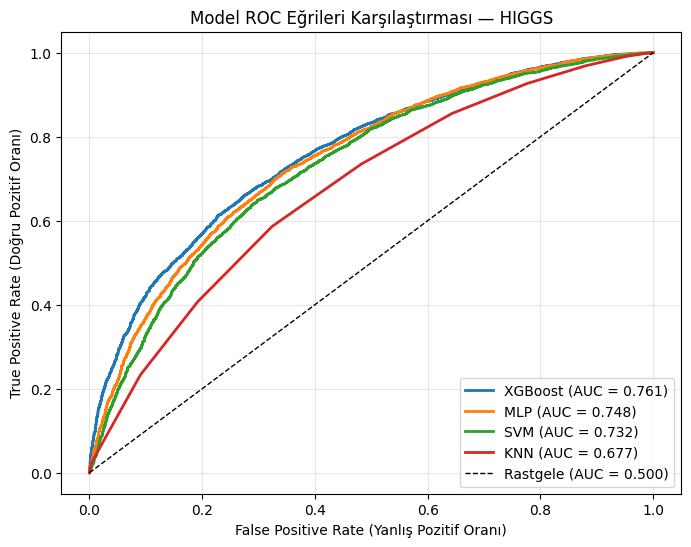

In [37]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

for model_name in sorted(sort_key, key=sort_key.get, reverse=True):
    y_score = oof_scores[model_name]          # fold-dışı skorlar
    fpr, tpr, _ = roc_curve(y_sub, y_score)   # ROC noktaları
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{model_name} (AUC = {roc_auc:.3f})")

# Rastgele tahmin çizgisi (köşegen)
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Rastgele (AUC = 0.500)")

plt.xlabel("False Positive Rate (Yanlış Pozitif Oranı)")
plt.ylabel("True Positive Rate (Doğru Pozitif Oranı)")
plt.title("Model ROC Eğrileri Karşılaştırması — HIGGS")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig("roc_egrileri.png", dpi=150, bbox_inches="tight")  # rapora eklemek için kaydet
plt.show()